# **From one neuron to a trained network**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)

# 📖 TABLE OF CONTENTS

- [Setup](#Setup)
- [One neuron was the atom. Now build the molecule.](#One-neuron-was-the-atom.-Now-build-the-molecule.)
  - [Step 1 — declare the network](#Step-1-—-declare-the-network)
  - [Step 2 — push data through](#Step-2-—-push-data-through)
  - [Step 3 — turn wrongness into a number](#Step-3-—-turn-wrongness-into-a-number)
  - [Step 4 — choose a step size](#Step-4-—-choose-a-step-size)
  - [Step 5 — run the training loop](#Step-5-—-run-the-training-loop)
- [References](#References)

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)

# Setup

Before we jump in, let's quickly run the setup cell. It checks the environment (GPU, library versions) and sets random seeds for reproducibility — we want identical results on every run.

In [1]:
# 🔧 Setup: Run this cell first!
# Environment check + random seeds for reproducibility

import sys
import time
import random
import numpy as np
import pandas as pd
import matplotlib as mpl
import torch
import torch.nn as nn

print(f"📦 Python  {sys.version.split()[0]}")
print(f"🔢 NumPy   {np.__version__}")
print(f"📊 Matplotlib   {mpl.__version__}")
print(f"🔥 PyTorch {torch.__version__}")

# GPU check (only needed for optional deep-feature experiments)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected")

DEVICE_LABEL = "GPU" if device.type == "cuda" else "CPU"

# Random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"\n🎲 Random seed set to {SEED} (Python, NumPy, PyTorch)")

%matplotlib inline
%config InlineBackend.figure_format = 'jpeg'   # photos as JPEG, not PNG — ~10× smaller notebook
# Remove character limits for all columns of Pandas dataframes permanently in this session
pd.set_option('display.max_colwidth', None)

📦 Python  3.12.13
🔢 NumPy   2.0.2
📊 Matplotlib   3.10.0
🔥 PyTorch 2.11.0+cpu
⚠️ No GPU detected

🎲 Random seed set to 42 (Python, NumPy, PyTorch)


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)

# One neuron was the atom. Now build the molecule.

Last lesson you computed a single neuron by hand. A layer is just many of those neurons sharing the same inputs, and a network is layers stacked with a non-linearity between them.

In this lesson you'll build a real image classifier, push data through it, measure how wrong it is, and then watch it get less wrong.

## Step 1 — declare the network

`nn.Sequential` runs the modules you list in order. 784 inputs is a 28×28 image flattened; 10 outputs is one score per digit.

In [2]:
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)
print(f"Layer stack: \n{model}")

Layer stack: 
Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)


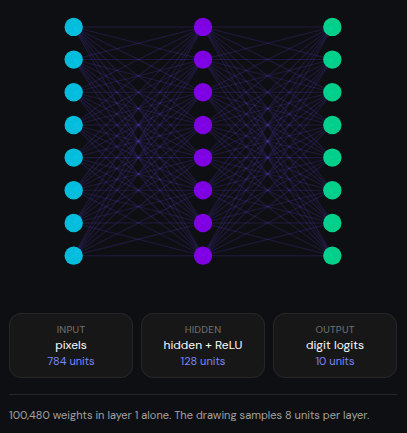

*Architecture*

In [3]:
from IPython.display import Image, display, Markdown
display(Image(filename="data/images/02_first_network/01-architecture.png", width=500))
display(Markdown("*Architecture*"))

Layer one holds 784 × 128 = 100,352 weights plus 128 biases. Those are the numbers training will change.

## Step 2 — push data through

A forward pass is just the neuron math from lesson 1, repeated layer after layer.

In [4]:
x = torch.randn(1, 784)
logits = model(x)
print(f"Logits shape: {logits.shape}")
print(f"Index of the max value in logits: {logits.argmax().item()}")

Logits shape: torch.Size([1, 10])
Index of the max value in logits: 2


We sent one random image in and got ten logits out.

The network confidently predicts something. It's wrong — it has never seen a label. Confidence without training means nothing.

## Step 3 — turn wrongness into a number

Cross-entropy loss compares the predicted distribution with the true label and returns a single scalar. A random 10-class model starts near $-ln(0.1) = ln(10) ≈ 2.30$ — if your loss doesn't start there, something is already broken.

In [5]:
loss_fn = nn.CrossEntropyLoss()
y = torch.tensor([3])
print(f"Loss: {loss_fn(logits, y).item()}")

Loss: 2.4326486587524414


## Step 4 — choose a step size

Backpropagation tells every weight which direction reduces the loss. The learning rate decides how far along that direction you actually step.

The default 0.001 is far too timid for this toy problem. Hence, we set LR to 0.05.

In [6]:
LR = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

## Step 5 — run the training loop

Zero the gradients, forward pass, compute loss, backward pass, step. After training for enough epochs, the weights stop being random.

In [8]:
# Specify inputs and targets for training
inputs = torch.randn(64, 784)  # 64 random inputs
targets = torch.randint(0, 10, (64,))  # 64 random targets (digits from 0 to 9)
EPOCHS = 100

for epoch in range(EPOCHS):
    optimizer.zero_grad()  # Zero the gradients
    logits = model(inputs)  # Forward pass
    loss = loss_fn(logits, targets)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Step
    print(f"Epoch {epoch + 1}/{EPOCHS} | Loss: {loss.item()}")

Epoch 1/100 | Loss: 2.335688591003418
Epoch 2/100 | Loss: 2.187471866607666
Epoch 3/100 | Loss: 2.050339460372925
Epoch 4/100 | Loss: 1.922106385231018
Epoch 5/100 | Loss: 1.8023688793182373
Epoch 6/100 | Loss: 1.6900392770767212
Epoch 7/100 | Loss: 1.584050178527832
Epoch 8/100 | Loss: 1.484179139137268
Epoch 9/100 | Loss: 1.39011812210083
Epoch 10/100 | Loss: 1.301090121269226
Epoch 11/100 | Loss: 1.217525839805603
Epoch 12/100 | Loss: 1.1386630535125732
Epoch 13/100 | Loss: 1.0642344951629639
Epoch 14/100 | Loss: 0.9942591786384583
Epoch 15/100 | Loss: 0.9284261465072632
Epoch 16/100 | Loss: 0.8666409254074097
Epoch 17/100 | Loss: 0.8088328838348389
Epoch 18/100 | Loss: 0.7547829747200012
Epoch 19/100 | Loss: 0.704491376876831
Epoch 20/100 | Loss: 0.6577404141426086
Epoch 21/100 | Loss: 0.6141822934150696
Epoch 22/100 | Loss: 0.5737069845199585
Epoch 23/100 | Loss: 0.5362573266029358
Epoch 24/100 | Loss: 0.501621663570404
Epoch 25/100 | Loss: 0.4695701003074646
Epoch 26/100 | Loss: 

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)

# References

- **[Learnism: Deep Learning — Neural Networks from Scratch Course](https://www.learnism.in/course/deep-learning)**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)